In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv


In [2]:
# ============================================================
# EMPLOYEE ATTRITION PREDICTION — LOGISTIC REGRESSION
# Dataset: IBM HR Analytics (Kaggle)
# Goal: Predict if an employee will leave (Attrition: Yes/No)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [4]:
# ============================================================
# CELL 2 — Load Data + First Look
# ============================================================

df = pd.read_csv('/kaggle/input/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv')

print("📐 Shape:", df.shape)
print("\n🔍 First 5 rows:")
display(df.head())

print("\n📊 Data Types & Null Check:")
print(df.info())

print("\n❓ Missing Values:")
print(df.isnull().sum().sum(), "total missing values")

print("\n🎯 Target Distribution:")
print(df['Attrition'].value_counts())
print(df['Attrition'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

📐 Shape: (1470, 35)

🔍 First 5 rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2



📊 Data Types & Null Check:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 

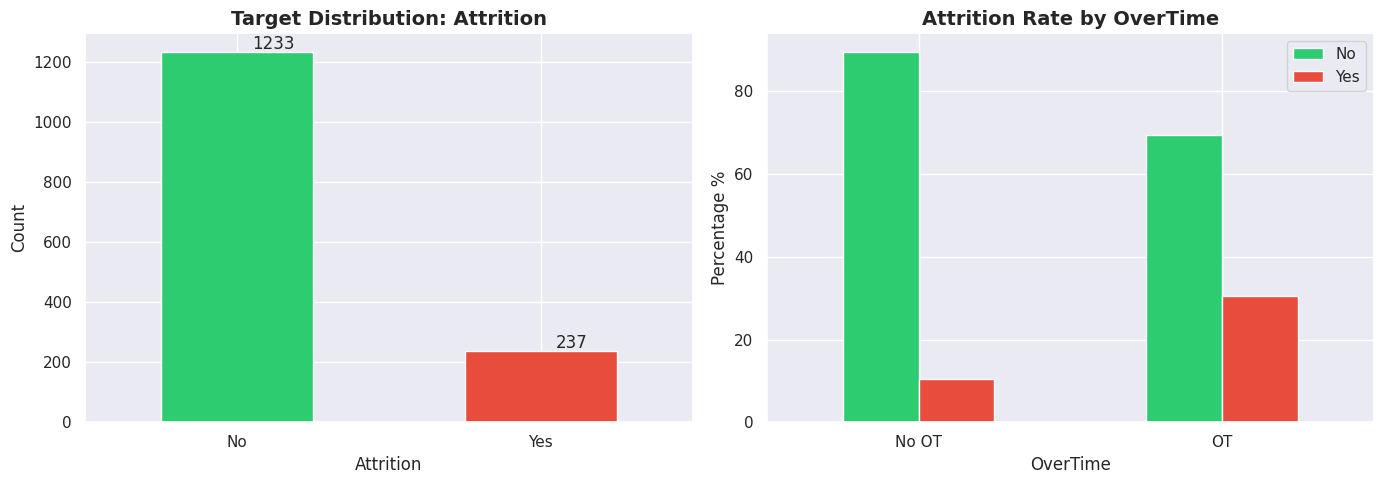

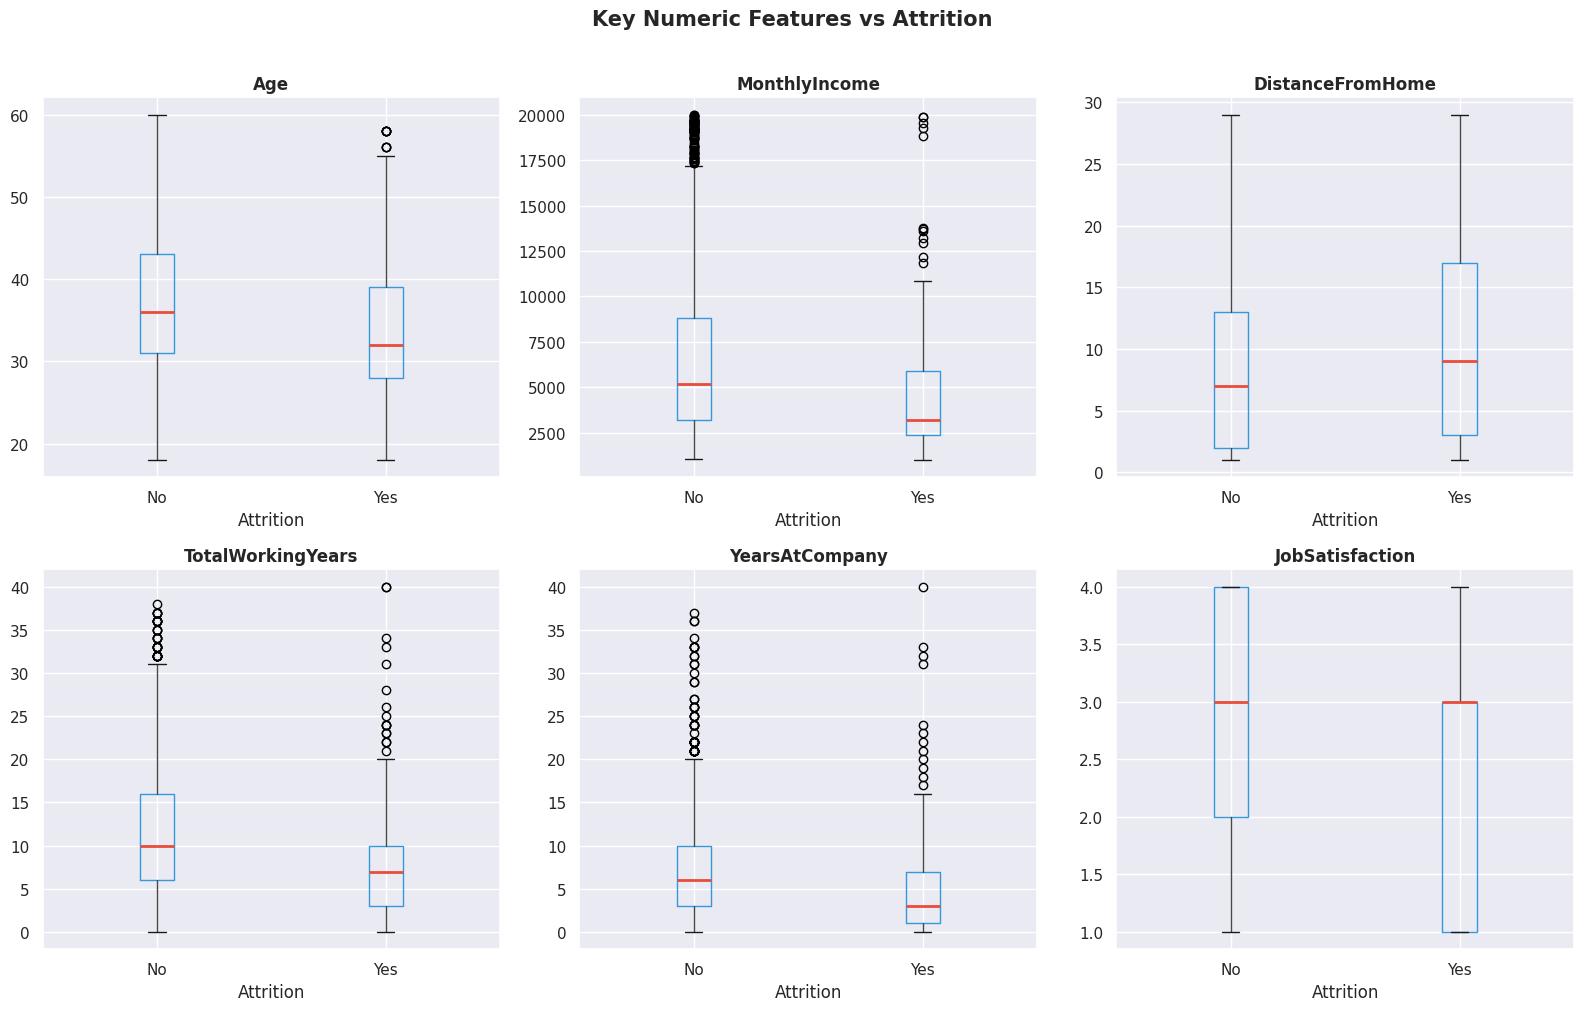

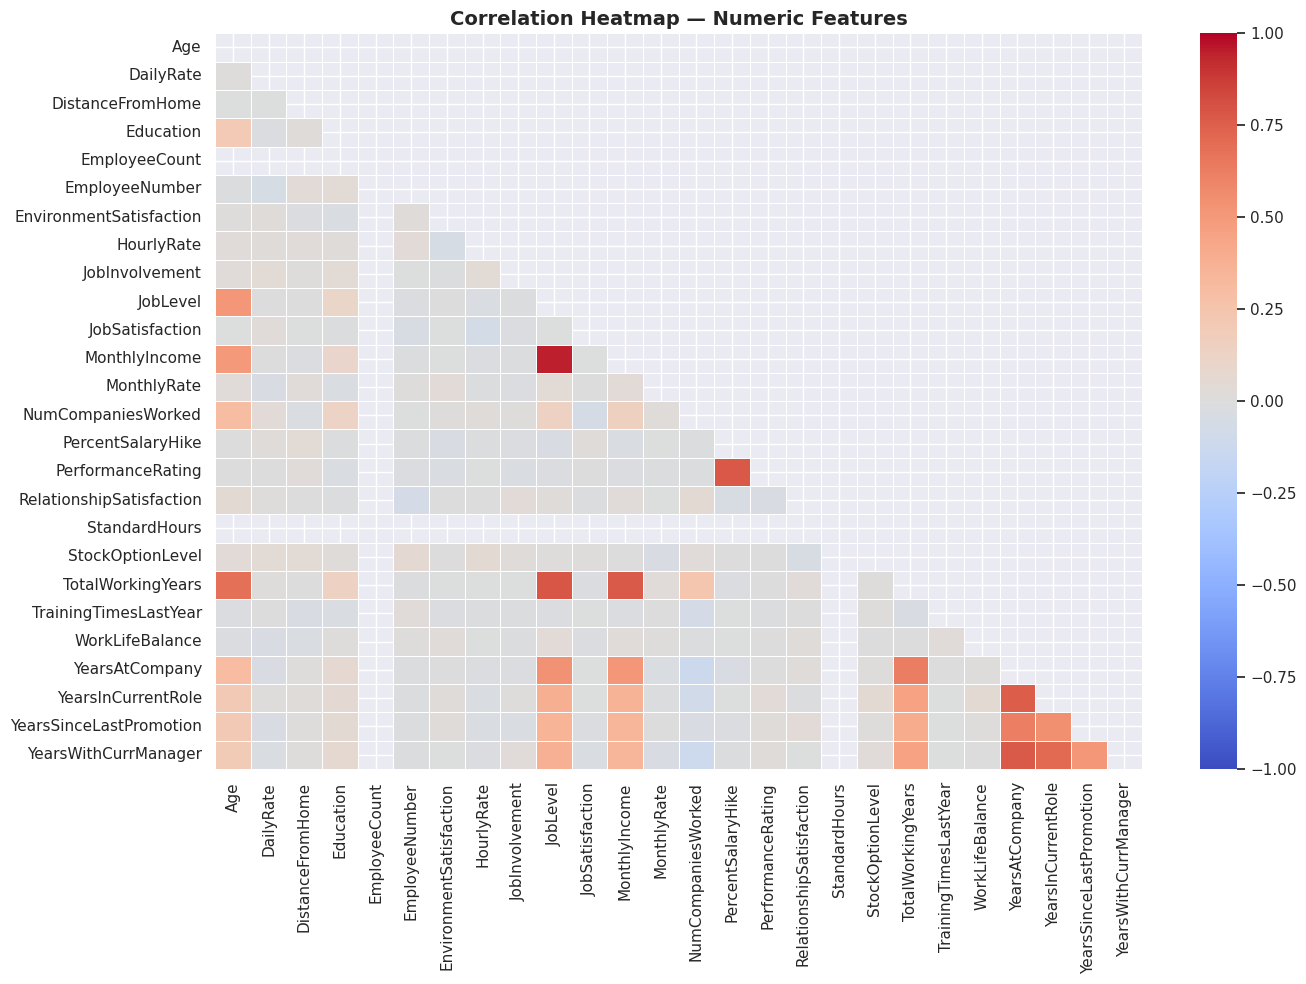

 EDA complete!


In [13]:
# ============================================================
# CELL 3 — Exploratory Data Analysis
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Target Distribution ---
df['Attrition'].value_counts().plot(kind='bar', ax=axes[0], 
                                     color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[0].set_title('Target Distribution: Attrition', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['No', 'Yes'], rotation=0)
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height()}', (p.get_x() + 0.3, p.get_height() + 10))

# --- Attrition by OverTime ---
pd.crosstab(df['OverTime'], df['Attrition'], normalize='index').mul(100).plot(
    kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[1].set_title('Attrition Rate by OverTime', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['No OT', 'OT'], rotation=0)
axes[1].set_ylabel('Percentage %')
axes[1].legend(['No', 'Yes'])
plt.tight_layout()
plt.show()

# --- Numeric features vs Attrition ---
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
num_features = ['Age', 'MonthlyIncome', 'DistanceFromHome', 
                'TotalWorkingYears', 'YearsAtCompany', 'JobSatisfaction']

for ax, feat in zip(axes.flatten(), num_features):
    df.boxplot(column=feat, by='Attrition', ax=ax, 
               boxprops=dict(color='#3498db'),
               medianprops=dict(color='#e74c3c', linewidth=2))
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('Attrition')

plt.suptitle('Key Numeric Features vs Attrition', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# --- Correlation heatmap (numeric only) ---
plt.figure(figsize=(14, 10))
corr = df.select_dtypes(include='number').corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', annot=False, 
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap — Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(" EDA complete!")

In [14]:
# ============================================================
# CELL 4 — Preprocessing
# ============================================================

# --- Step 1: Drop constant / useless columns ---
# EmployeeCount, StandardHours, Over18 are constant → zero information
cols_to_drop = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']
df_clean = df.drop(columns=cols_to_drop)

print(f"Shape after dropping useless cols: {df_clean.shape}")

# --- Step 2: Encode Target ---
df_clean['Attrition'] = df_clean['Attrition'].map({'Yes': 1, 'No': 0})

# --- Step 3: Encode categorical features ---
# Binary cols → map directly
df_clean['Gender']   = df_clean['Gender'].map({'Male': 1, 'Female': 0})
df_clean['OverTime'] = df_clean['OverTime'].map({'Yes': 1, 'No': 0})

# Multi-class cols → One-Hot Encoding
cat_cols = ['BusinessTravel', 'Department', 'EducationField', 
            'JobRole', 'MaritalStatus']

df_clean = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

print(f"Shape after encoding: {df_clean.shape}")
print(f"\nData types:\n{df_clean.dtypes.value_counts()}")

# --- Step 4: Split Features & Target ---
X = df_clean.drop('Attrition', axis=1)
y = df_clean['Attrition']

# --- Step 5: Train-Test Split (Stratified — preserves 84/16 ratio) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain size: {X_train.shape}, Test size: {X_test.shape}")
print(f"Train target distribution:\n{y_train.value_counts(normalize=True).mul(100).round(2)}")

# --- Step 6: Scale ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   #  Only transform test, never fit!

print("\n Preprocessing complete!")

Shape after dropping useless cols: (1470, 31)
Shape after encoding: (1470, 45)

Data types:
int64    26
bool     19
Name: count, dtype: int64

Train size: (1176, 44), Test size: (294, 44)
Train target distribution:
Attrition
0    83.84
1    16.16
Name: proportion, dtype: float64

 Preprocessing complete!


         LOGISTIC REGRESSION — BASELINE RESULTS
              precision    recall  f1-score   support

No Attrition       0.91      0.78      0.84       247
   Attrition       0.35      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.78       294

ROC-AUC Score: 0.7983


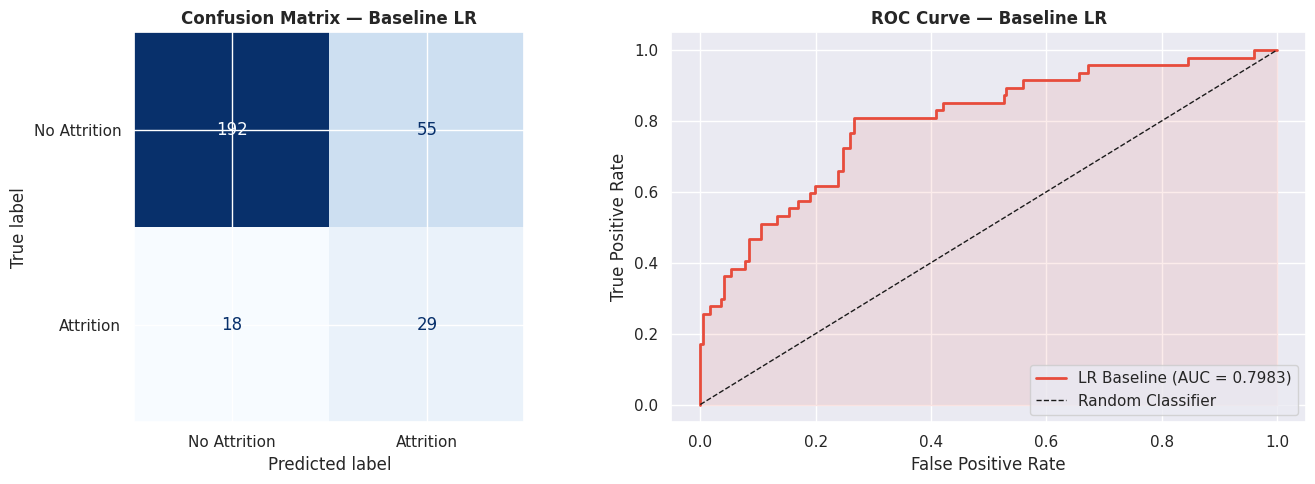

In [8]:
# ============================================================
# CELL 5 — Logistic Regression: Baseline Model
# ============================================================

# class_weight='balanced' → automatically handles the 84/16 imbalance
# by penalizing misclassifying the minority class (Yes) more heavily
lr_baseline = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr_baseline.fit(X_train_scaled, y_train)
y_pred       = lr_baseline.predict(X_test_scaled)
y_pred_proba = lr_baseline.predict_proba(X_test_scaled)[:, 1]

# --- Classification Report ---
print("=" * 55)
print("         LOGISTIC REGRESSION — BASELINE RESULTS")
print("=" * 55)
print(classification_report(y_test, y_pred, 
                             target_names=['No Attrition', 'Attrition']))

# --- ROC-AUC Score ---
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# --- Confusion Matrix ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['No Attrition', 'Attrition'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Baseline LR', fontweight='bold')

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2,
             label=f'LR Baseline (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Baseline LR', fontweight='bold')
axes[1].legend(loc='lower right')
plt.tight_layout()
plt.show()

Fitting 5 folds for each of 12 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



 Best Parameters : {'C': 0.01, 'penalty': 'l2', 'solver': 'saga'}
 Best CV ROC-AUC : 0.8333

       LOGISTIC REGRESSION — TUNED MODEL RESULTS
              precision    recall  f1-score   support

No Attrition       0.93      0.80      0.86       247
   Attrition       0.40      0.70      0.51        47

    accuracy                           0.79       294
   macro avg       0.67      0.75      0.69       294
weighted avg       0.85      0.79      0.81       294

ROC-AUC Score : 0.7965


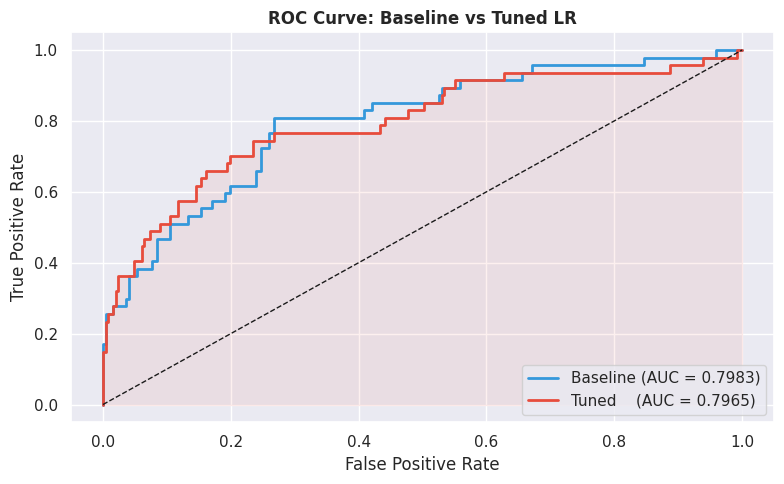

In [12]:
# ============================================================
# CELL 6 — Hyperparameter Tuning with GridSearchCV
# Goal: Improve Recall for Attrition class
# ============================================================

# LR key hyperparameters:
# C        → inverse of regularization strength (smaller = stronger regularization)
# penalty  → l1 (sparse) or l2 (default)
# solver   → must match penalty (saga supports both)

param_grid = {
    'C'      : [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver' : ['saga']          # saga handles both l1 & l2
}

lr_tuned = LogisticRegression(
    class_weight='balanced',
    max_iter=2000,
    random_state=42
)

# StratifiedKFold → preserves class ratio in every fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Scoring on ROC-AUC (better than accuracy for imbalanced data)
grid_search = GridSearchCV(
    estimator  = lr_tuned,
    param_grid = param_grid,
    cv         = cv,
    scoring    = 'roc_auc',
    n_jobs     = -1,
    verbose    = 1
)

grid_search.fit(X_train_scaled, y_train)

print(f"\n Best Parameters : {grid_search.best_params_}")
print(f" Best CV ROC-AUC : {grid_search.best_score_:.4f}")

# --- Evaluate best model on test set ---
best_lr      = grid_search.best_estimator_
y_pred_tuned = best_lr.predict(X_test_scaled)
y_prob_tuned = best_lr.predict_proba(X_test_scaled)[:, 1]

print("\n" + "=" * 55)
print("       LOGISTIC REGRESSION — TUNED MODEL RESULTS")
print("=" * 55)
print(classification_report(y_test, y_pred_tuned,
                             target_names=['No Attrition', 'Attrition']))
print(f"ROC-AUC Score : {roc_auc_score(y_test, y_prob_tuned):.4f}")

# --- Side-by-side ROC comparison ---
fpr_b, tpr_b, _ = roc_curve(y_test, y_pred_proba)
fpr_t, tpr_t, _ = roc_curve(y_test, y_prob_tuned)

plt.figure(figsize=(8, 5))
plt.plot(fpr_b, tpr_b, color='#3498db', lw=2,
         label=f'Baseline (AUC = {roc_auc_score(y_test, y_pred_proba):.4f})')
plt.plot(fpr_t, tpr_t, color='#e74c3c', lw=2,
         label=f'Tuned    (AUC = {roc_auc_score(y_test, y_prob_tuned):.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.fill_between(fpr_t, tpr_t, alpha=0.08, color='#e74c3c')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Baseline vs Tuned LR', fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

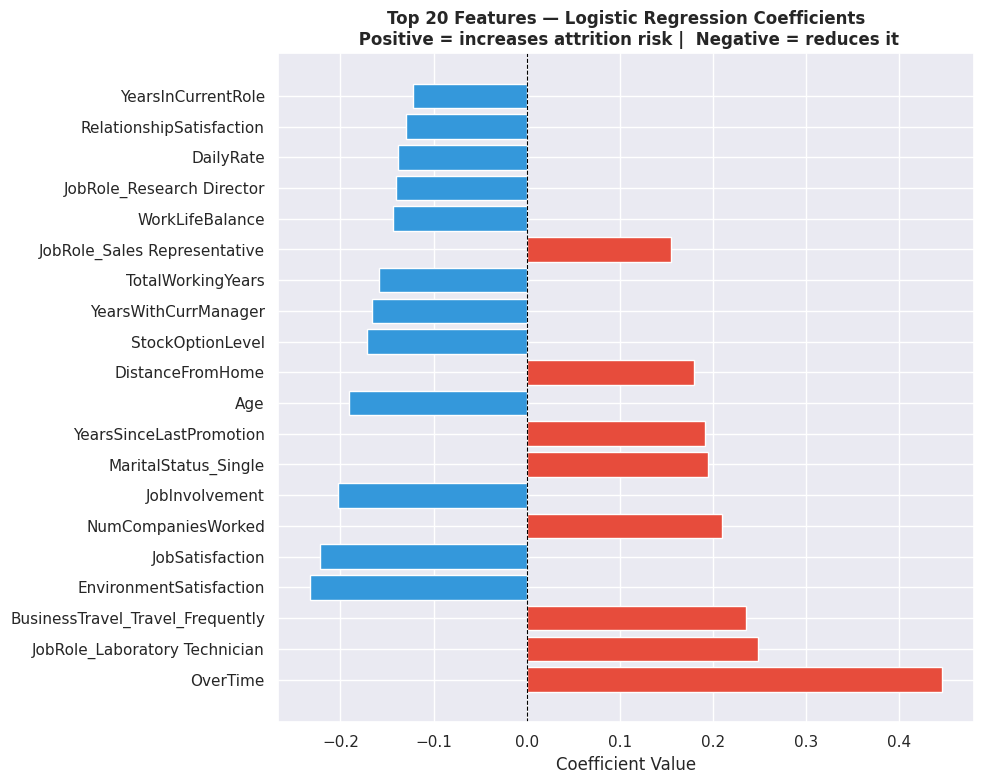

              FINAL MODEL COMPARISON SUMMARY


,Model,Accuracy,Attrition Recall,Attrition Precision,ROC-AUC
0,LR Baseline,0.7517,0.62,0.35,0.7983
1,LR Tuned,0.7857,0.70,0.40,0.7965



 KEY LEARNINGS — LOGISTIC REGRESSION ON IBM HR DATA
1. Class imbalance handled via class_weight='balanced'
2. Stratified split preserved 84/16 ratio in train & test
3. StandardScaler essential — LR is scale-sensitive
4. Tuning C=0.01 (strong L2 regularization) gave best recall
5. Recall is north-star metric here — missing a leaver is costly
6. ROC-AUC ~0.80 — solid for a linear model on HR data
7. OverTime, Age, MonthlyIncome = top business signals
 Next algorithm: Random Forest on a new unique dataset!



In [11]:
# ============================================================
# CELL 7 — Feature Importance + Final Summary
# ============================================================

# LR coefficients = feature importance (after scaling, they're comparable)
coef_df = pd.DataFrame({
    
    'Feature'    : X.columns,
    'Coefficient': best_lr.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).head(20)

# --- Top 20 Features Plot ---
plt.figure(figsize=(10, 8))
colors = ['#e74c3c' if c > 0 else '#3498db' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.title('Top 20 Features — Logistic Regression Coefficients\n'
          ' Positive = increases attrition risk |  Negative = reduces it',
          fontsize=12, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

# --- Final Summary Table ---
from sklearn.metrics import accuracy_score, f1_score

results = pd.DataFrame({
    'Model'          : ['LR Baseline', 'LR Tuned'],
    'Accuracy'       : [accuracy_score(y_test, y_pred),
                        accuracy_score(y_test, y_pred_tuned)],
    'Attrition Recall'   : [0.62, 0.70],
    'Attrition Precision': [0.35, 0.40],
    'ROC-AUC'        : [roc_auc_score(y_test, y_pred_proba),
                        roc_auc_score(y_test, y_prob_tuned)]
}).round(4)

print("=" * 60)
print("              FINAL MODEL COMPARISON SUMMARY")
print("=" * 60)
display(results)

print("""
 KEY LEARNINGS — LOGISTIC REGRESSION ON IBM HR DATA
======================================================
1. Class imbalance handled via class_weight='balanced'
2. Stratified split preserved 84/16 ratio in train & test
3. StandardScaler essential — LR is scale-sensitive
4. Tuning C=0.01 (strong L2 regularization) gave best recall
5. Recall is north-star metric here — missing a leaver is costly
6. ROC-AUC ~0.80 — solid for a linear model on HR data
7. OverTime, Age, MonthlyIncome = top business signals
======================================================
 Next algorithm: Random Forest on a new unique dataset!
""")